In [4]:
# --- 1.  pull the symmetry straight from the module -----------------
from orix.quaternion.symmetry import O, Oh   # cubic, w/ or w/o inversion

sym = Oh        # full m-3m symmetry for γ-Ni (Inconel 718 matrix)

# --- 2. or, derive it from the space-group number -------------------
from orix.quaternion.symmetry import get_point_group

sym     = get_point_group(225)          # → Oh  (m-3m)
sym_fcc = get_point_group(225, proper=True)   # → O   (432)

import orix, importlib, pathlib, sys
print("orix version:", orix.__version__)
print("loaded from :", pathlib.Path(orix.__file__))

import inspect, orix
from orix.quaternion import Orientation
print(inspect.getfile(Orientation))
import numpy as np
from orix.quaternion import Orientation
from orix.quaternion.symmetry import get_point_group
from orix.vector import Vector3d
from orix.plot import IPFColorKeyTSL           # still available for legacy colour keys

orix version: 0.13.3
loaded from : /home/umang/miniconda3/envs/material/lib/python3.10/site-packages/orix/__init__.py
/home/umang/miniconda3/envs/material/lib/python3.10/site-packages/orix/quaternion/orientation.py


In [5]:
sym_fcc = get_point_group(225, proper=True)    # cubic 432

def quaternion_to_ipf(quats, axis="Z"):
    ori = Orientation(np.asarray(quats), symmetry=sym_fcc)

    key = IPFColorKeyTSL(
        sym_fcc,
        direction=getattr(Vector3d, f"{axis.lower()}vector")()
    )
    return key.orientation2color(ori)          # (N, 3) in 0–1 RGB


[[1.00000000e+00 1.11022302e-16 0.00000000e+00]
 [5.27049472e-03 1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 1.11022302e-16 0.00000000e+00]]
[[1.00000000e+00 1.11022302e-16 0.00000000e+00]
 [4.91822244e-01 1.00000000e+00 2.84206240e-01]
 [1.40418575e-01 1.33115863e-01 1.00000000e+00]]


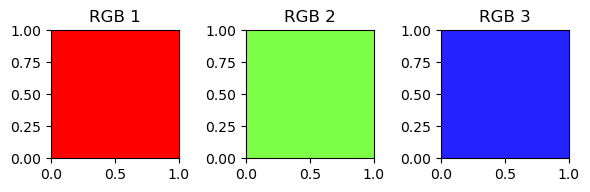

In [6]:
Qs = [
    [1, 0, 0, 0],
    [0.92388, 0, 0.38268, 0],
    [0.70711, 0.70711, 0, 0],
]
print(quaternion_to_ipf(Qs, axis="Z"))

# get RGB colours for Qs
import os

#Example with three orientations
Qs = [
    [1, 0, 0, 0],      # identity
    [0.94177115, 0.07504171, -0.29972738, -0.13266438 ],     # supposed to be BLUE orientation
    [ 0.86994576, 0.3598948, 0.32445887, 0.09163266,]   # supposed to be GREEN orientation
]
rgbs = quaternion_to_ipf(Qs, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

# display RGB colours
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(rgbs), figsize=(len(rgbs)*2, 2))
for i, rgb in enumerate(rgbs):
    axes[i].add_patch(mpatches.Rectangle((0, 0), 1, 1, color=rgb))
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'RGB {i+1}')
    axes[i].set_aspect('equal')
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
# load npy file 
fz_npy_path= "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/sr_save/sr_save_qrbsa_1d_model_best_minimum_angle_transformation.npy"
fz_data = np.load(fz_npy_path)

In [8]:
# load original median indices
median_indices_path = "/home/umang/a100_mount/Materials/QRBSA-data-augmentation/Quaternion_experiments/transposeConv_multipass_outerprod_kernel_3,4_extra_conv/sr_save/sr_median_indices_qrbsa_1d_model_best_minimum_angle_transformation.npy"
median_indices = np.load(median_indices_path)
# send 1st dim to last for median indices
median_indices = np.moveaxis(median_indices, 1, -1)
median_indices.shape

(1, 304, 390, 4)

In [9]:
fz_data = fz_data[:, :301, :390, :]
median_indices = median_indices[:, :301, :390, :]
median_indices.shape, fz_data.shape

((1, 301, 390, 4), (100, 301, 390, 4))

In [10]:
# pool median quaternions from data using median indices
# median indices shape (1, 301, 390, 4), data shape  (100, 301, 390, 4)

fz_pooled_data = np.zeros((1, median_indices.shape[1], median_indices.shape[2], fz_data.shape[-1]))
for i in range(median_indices.shape[1]):
    for j in range(median_indices.shape[2]):
        fz_pooled_data[0, i, j, :] = fz_data[median_indices[0,i,j,0], i,j,:]
fz_pooled_data.shape

(1, 301, 390, 4)

In [11]:
fz_pooled_data_sampled = fz_pooled_data[:, 140:220, 90:220, :]
print(fz_pooled_data_sampled[:, 0, 0:10, :])

[[[-0.35491991  0.28599367 -0.18019956  0.87164658]
  [ 0.35929981  0.32735288  0.07369888  0.87081176]
  [ 0.36061129  0.32475135  0.07580052  0.8710624 ]
  [ 0.36028659  0.3229546   0.07345694  0.87206542]
  [-0.35839033  0.27933127 -0.16930109  0.87456745]
  [-0.35585028  0.28216347 -0.16234644  0.8760125 ]
  [ 0.36038378  0.32446939  0.07694571  0.87116194]
  [ 0.36063606  0.3240574   0.07729717  0.87117976]
  [-0.35617211  0.28194529 -0.16142388  0.87612247]
  [ 0.35437757  0.31967306  0.07527435  0.87553388]]]


In [12]:
# get RGB colours for Qs
import os
#Example with three orientations
Qs = fz_pooled_data  # Convert numpy array to list
# bring last quaternion dimension to the front (Scalar first)
# reshape Qs to (-1, 4) if needed
q = np.asarray(Qs).reshape(-1, 4)  # Flatten if necessary

# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

[[ 0.97333139  0.15701585 -0.13723239 -0.09559351]
 [ 0.97539288  0.14938469 -0.13193329 -0.09426371]
 [ 0.97371155  0.15385662 -0.13844338 -0.09511177]
 ...
 [ 0.90283024  0.05777854  0.33842897 -0.25889215]
 [ 0.90574527  0.05474241  0.33727899 -0.250741  ]
 [ 0.90590829  0.05651183  0.33680835 -0.25039339]]
[[1.         0.06682046 0.74499735]
 [1.         0.07145917 0.69459933]
 [1.         0.09632632 0.73522281]
 ...
 [0.48606637 0.89207115 1.        ]
 [0.48604302 0.93338284 1.        ]
 [0.49086345 0.92206944 1.        ]]


In [13]:
print("Shape of rgbs:", rgbs.shape)  # Check the shape of the RGB array

#reshape rgbs to match the original data shape
rgbs_reshaped = rgbs.reshape(1, median_indices.shape[1], median_indices.shape[2], 3)
print("Shape of reshaped rgbs:", rgbs_reshaped.shape)  # Should match (1, 301, 390, 3)

Shape of rgbs: (117390, 3)
Shape of reshaped rgbs: (1, 301, 390, 3)


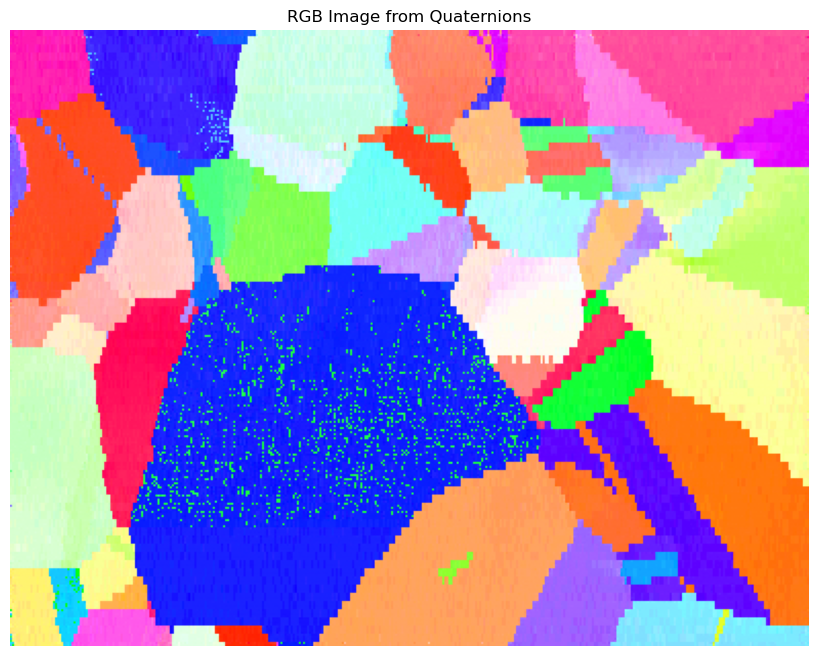

In [14]:
# plot rgbs_reshaped as an image
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(rgbs_reshaped[0])
plt.axis('off')
plt.title('RGB Image from Quaternions')
plt.show()

## Now analyze spectrum of green pixels.

### find location of green pixels in the blue grain.

Shape of blue grain: (80, 130, 3)


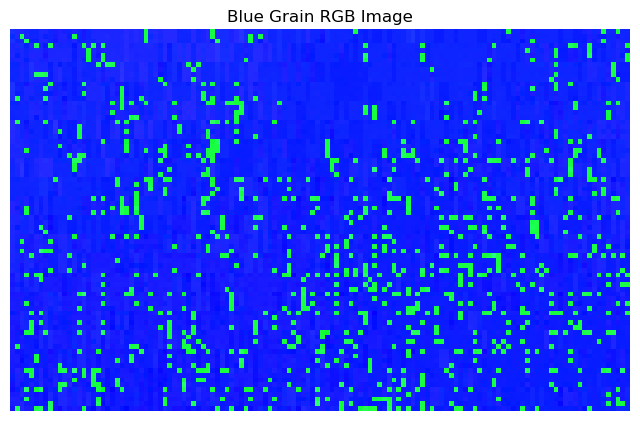

In [16]:
blue_grain = rgbs_reshaped[0, 140:220, 90:220, :]
print("Shape of blue grain:", blue_grain.shape)  # Should be (80, 130, 3)

# show the blue grain
plt.figure(figsize=(8, 6))
plt.imshow(blue_grain)
plt.axis('off')
plt.title('Blue Grain RGB Image')
plt.show()

Cluster labels shape: (10400,)


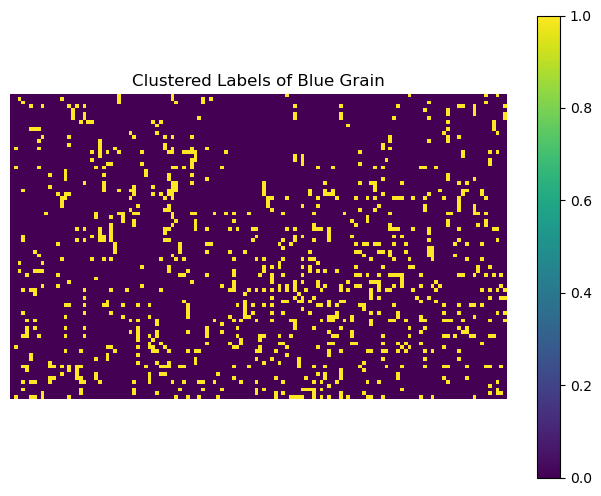

In [19]:
# Now run k-means clustering on the blue grain RGB with 2 clusters
from sklearn.cluster import KMeans
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
# Reshape the blue grain for clustering
blue_grain_reshaped = blue_grain.reshape(-1, 3)  # Flatten the image to (N, 3) for clustering
kmeans.fit(blue_grain_reshaped)
clustered_labels = kmeans.labels_
print("Cluster labels shape:", clustered_labels.shape)  # Should be (80*130,)

# Visualize the clustered labels
import matplotlib.pyplot as plt
clustered_image = clustered_labels.reshape(blue_grain.shape[0], blue_grain.shape[1])
plt.figure(figsize=(8, 6))
plt.imshow(clustered_image, cmap='viridis', interpolation='nearest')
plt.axis('off')
plt.title('Clustered Labels of Blue Grain')
plt.colorbar()
plt.show()

In [20]:
# find location of green pixels in the blue grain.
green_pixels = np.where(clustered_image == 1)  # Assuming cluster 1 is the green cluster
green_pixel_coords = list(zip(green_pixels[0], green_pixels[1]))
print("Green pixel coordinates in the blue grain:", green_pixel_coords)

Green pixel coordinates in the blue grain: [(0, 28), (0, 42), (0, 72), (0, 104), (0, 124), (0, 127), (1, 2), (1, 13), (1, 28), (1, 42), (1, 50), (1, 52), (2, 3), (2, 28), (2, 43), (2, 50), (2, 109), (2, 124), (3, 5), (3, 8), (3, 15), (3, 17), (3, 19), (3, 74), (3, 86), (3, 101), (3, 117), (3, 118), (3, 121), (3, 129), (4, 16), (4, 108), (4, 114), (4, 121), (5, 16), (5, 19), (5, 74), (5, 86), (5, 114), (5, 121), (5, 129), (6, 16), (6, 19), (6, 49), (6, 74), (6, 86), (6, 100), (6, 109), (6, 129), (7, 18), (7, 20), (7, 21), (7, 37), (7, 39), (7, 114), (7, 126), (8, 38), (8, 88), (8, 126), (9, 5), (9, 6), (9, 7), (9, 114), (9, 126), (10, 31), (10, 38), (10, 113), (10, 127), (11, 8), (11, 15), (11, 32), (11, 40), (11, 42), (11, 47), (11, 99), (11, 114), (11, 117), (12, 7), (12, 23), (12, 99), (12, 109), (12, 114), (13, 15), (13, 23), (13, 40), (13, 97), (14, 1), (14, 7), (14, 23), (14, 27), (14, 40), (14, 42), (14, 47), (14, 51), (14, 97), (14, 99), (15, 21), (15, 23), (15, 25), (15, 28), (

In [27]:
# Vectorized extraction of green quaternions from fz_data at green pixel locations
green_pixel_rows = np.array([coord[0] for coord in green_pixel_coords])
green_pixel_cols = np.array([coord[1] for coord in green_pixel_coords])

# Adjust indices based on the blue grain crop
i_idx = green_pixel_rows + 140
j_idx = green_pixel_cols + 90

# Use advanced indexing to extract all at once
green_quaternions = fz_data[:, i_idx, j_idx, :]  # shape: (100, N, 4)

In [29]:
assert green_quaternions.shape[1] == len(green_pixel_coords), "Mismatch in number of green quaternions and coordinates"

In [ ]:
print("Shape of green quaternions:", green_quaternions.shape)  # Should be (100, N, 4) where N is the number of green pixels

Shape of green quaternions: (100, 945, 4)


[[ 0.8716644   0.36092776  0.321178    0.08232296]
 [ 0.873853    0.3618732   0.31484884  0.07936577]
 [ 0.8741952   0.36177373  0.3141072   0.07898837]
 ...
 [ 0.8759949  -0.36219153  0.27517256 -0.16040479]
 [ 0.8764245  -0.35869363  0.27765346 -0.16163799]
 [ 0.8760825  -0.3617205   0.2760924  -0.15940556]]
[[0.11144867 0.14295364 1.        ]
 [0.06544527 0.1201288  1.        ]
 [0.06078231 0.11670502 1.        ]
 ...
 [0.03139827 0.09903535 1.        ]
 [0.03674266 0.1200932  1.        ]
 [0.03429823 0.1007153  1.        ]]
Shape of rgbs: (94500, 3)
Shape of reshaped rgbs: (1, 100, 945, 3)


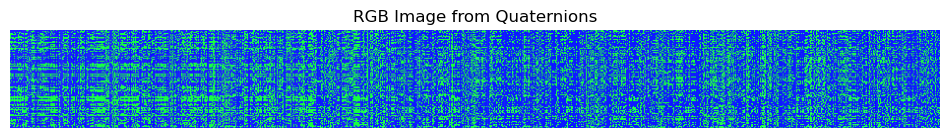

In [ ]:
# rows will N and col will be 100. 
# get RGB colours for Qs
import os
# subsample green quaternions for visualization, every 10th.
subsampled_green_quaternions = green_quaternions[:, :, :]  # Subsample every 10th quaternion for visualization
print("Shape of subsampled green quaternions:", subsampled_green_quaternions.shape)

#Example with three orientations
Qs = subsampled_green_quaternions  # Convert numpy array to list
# bring last quaternion dimension to the front (Scalar first)
# reshape Qs to (-1, 4) if needed
q = np.asarray(Qs).reshape(-1, 4)  # Flatten if necessary

# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

print("Shape of rgbs:", rgbs.shape)  # Check the shape of the RGB array

#reshape rgbs to match the original data shape
rgbs_reshaped = rgbs.reshape(1, subsampled_green_quaternions.shape[0], subsampled_green_quaternions.shape[1], 3)
print("Shape of reshaped rgbs:", rgbs_reshaped.shape)  # Should match (1, 301, 390, 3)

# plot rgbs_reshaped as an image
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(rgbs_reshaped[0])
plt.axis('off')
plt.title('RGB Image from Quaternions')
plt.show()

Shape of rgbs: (9500, 3)
Shape of reshaped rgbs: (1, 100, 95, 3)


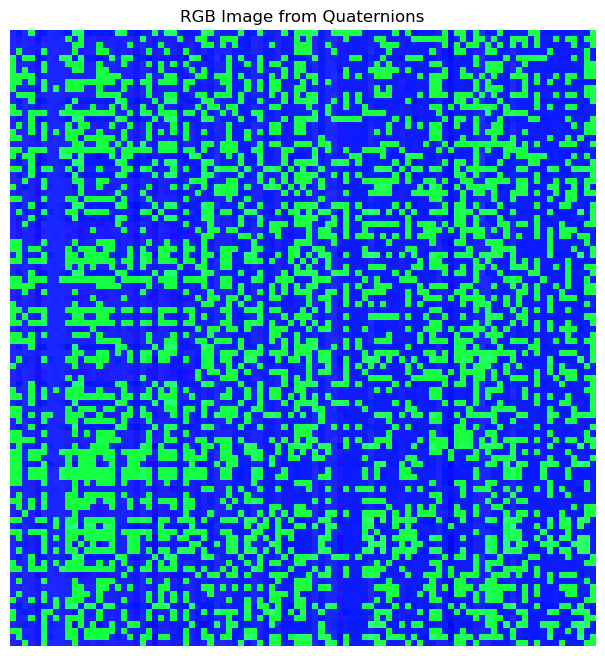

## get similar spectrum for blue pixels

In [48]:
# find location of blue pixels in the blue grain.
blue_pixels = np.where(clustered_image == 0)  # Assuming cluster 0 is blue cluster
blue_pixel_coords = list(zip(blue_pixels[0], blue_pixels[1]))
print("Blue pixel coordinates in the blue grain:", blue_pixel_coords)

Blue pixel coordinates in the blue grain: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (0, 20), (0, 21), (0, 22), (0, 23), (0, 24), (0, 25), (0, 26), (0, 27), (0, 29), (0, 30), (0, 31), (0, 32), (0, 33), (0, 34), (0, 35), (0, 36), (0, 37), (0, 38), (0, 39), (0, 40), (0, 41), (0, 43), (0, 44), (0, 45), (0, 46), (0, 47), (0, 48), (0, 49), (0, 50), (0, 51), (0, 52), (0, 53), (0, 54), (0, 55), (0, 56), (0, 57), (0, 58), (0, 59), (0, 60), (0, 61), (0, 62), (0, 63), (0, 64), (0, 65), (0, 66), (0, 67), (0, 68), (0, 69), (0, 70), (0, 71), (0, 73), (0, 74), (0, 75), (0, 76), (0, 77), (0, 78), (0, 79), (0, 80), (0, 81), (0, 82), (0, 83), (0, 84), (0, 85), (0, 86), (0, 87), (0, 88), (0, 89), (0, 90), (0, 91), (0, 92), (0, 93), (0, 94), (0, 95), (0, 96), (0, 97), (0, 98), (0, 99), (0, 100), (0, 101), (0, 102), (0, 103), (0, 105), (0, 106), (0, 107), (0, 108), (0, 109), (0, 

In [49]:
# Vectorized extraction of blue quaternions from fz_data at blue pixel locations
blue_pixel_rows = np.array([coord[0] for coord in blue_pixel_coords])
blue_pixel_cols = np.array([coord[1] for coord in blue_pixel_coords])

# Adjust indices based on the blue grain crop
i_idx = blue_pixel_rows + 140
j_idx = blue_pixel_cols + 90

# Use advanced indexing to extract all at once
blue_quaternions = fz_data[:, i_idx, j_idx, :]  # shape: (100, N, 4)

Shape of subsampled blue quaternions: (100, 946, 4)
[[ 0.8716466  -0.3549199   0.28599367 -0.18019956]
 [ 0.8732128   0.358207    0.32019764  0.08161294]
 [ 0.87245303 -0.35885185  0.286251   -0.16766489]
 ...
 [ 0.8759793   0.3623959   0.07884414 -0.30840322]
 [ 0.8757467  -0.3599782   0.27703914 -0.1634996 ]
 [ 0.8731421   0.358688    0.3199557   0.08120117]]
[[0.10915621 0.19091895 1.        ]
 [0.11481437 0.12930533 1.        ]
 [0.10694578 0.15063761 1.        ]
 ...
 [0.10929817 1.         0.29769509]
 [0.04054327 0.11776118 1.        ]
 [0.11024459 0.12983599 1.        ]]
Shape of rgbs: (94600, 3)
Shape of reshaped rgbs: (1, 100, 946, 3)


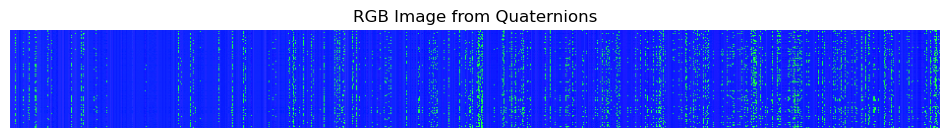

In [51]:
# rows will N and col will be 100. 
# get RGB colours for Qs
import os
# subsample blue quaternions for visualization, every 10th.
subsampled_blue_quaternions = blue_quaternions[:, ::10, :]  # Subsample every 10th quaternion for visualization
print("Shape of subsampled blue quaternions:", subsampled_blue_quaternions.shape)

#Example with three orientations
Qs = subsampled_blue_quaternions  # Convert numpy array to list
# bring last quaternion dimension to the front (Scalar first)
# reshape Qs to (-1, 4) if needed
q = np.asarray(Qs).reshape(-1, 4)  # Flatten if necessary

# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

print("Shape of rgbs:", rgbs.shape)  # Check the shape of the RGB array

#reshape rgbs to match the original data shape
rgbs_reshaped = rgbs.reshape(1, subsampled_blue_quaternions.shape[0], subsampled_blue_quaternions.shape[1], 3)
print("Shape of reshaped rgbs:", rgbs_reshaped.shape)  # Should match (1, 301, 390, 3)

# plot rgbs_reshaped as an image
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(rgbs_reshaped[0])
plt.axis('off')
plt.title('RGB Image from Quaternions')
plt.show()

In [58]:
# Vectorized extraction of blue quaternions from fz_data at blue pixel locations
blue_pixel_rows = np.array([coord[0] for coord in blue_pixel_coords])
blue_pixel_cols = np.array([coord[1] for coord in blue_pixel_coords])

# Adjust indices based on the blue grain crop
i_idx = blue_pixel_rows
j_idx = blue_pixel_cols
# Use advanced indexing to extract all at once
blue_median_quaternions = fz_pooled_data_sampled[0, i_idx, j_idx, :]  # shape: (100, N, 4)
    
# Adjust indices based on the green grain crop
i_idx = green_pixel_rows
j_idx = green_pixel_cols
# Use advanced indexing to extract all at once
green_median_quaternions = fz_pooled_data_sampled[0, i_idx, j_idx, :]  # shape: (100, N, 4)

In [59]:
blue_median_quaternions_scalar= blue_median_quaternions[..., -1].flatten()
green_median_quaternions_scalar = green_median_quaternions[..., -1].flatten()


In [64]:
blue_median_quaternions_scalar.shape, green_median_quaternions_scalar.shape

((9455,), (945,))

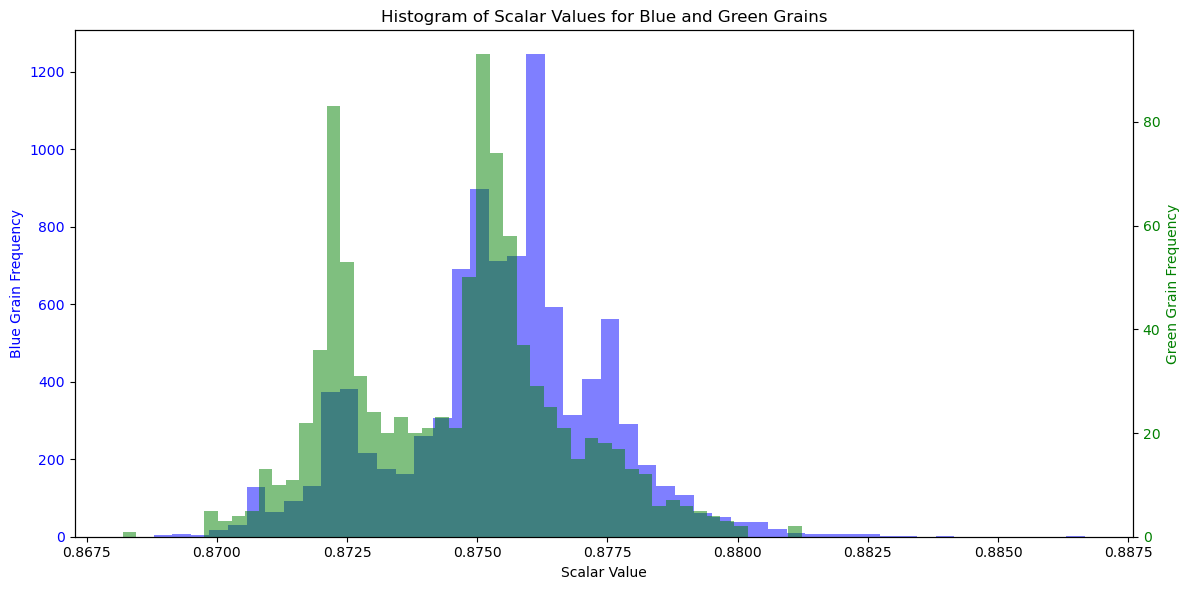

In [67]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'blue'
color2 = 'green'

# Plot blue grain histogram on ax1
ax1.hist(blue_median_quaternions_scalar, bins=50, alpha=0.5, label='Blue Grain', color=color1)
ax1.set_xlabel('Scalar Value')
ax1.set_ylabel('Blue Grain Frequency', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis for green grain
ax2 = ax1.twinx()
ax2.hist(green_median_quaternions_scalar, bins=50, alpha=0.5, label='Green Grain', color=color2)
ax2.set_ylabel('Green Grain Frequency', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Histogram of Scalar Values for Blue and Green Grains')
fig.tight_layout()
plt.show()

## Try clustering directly on quaternions

In [ ]:
# run kmeans on sampled fz data
sampled_fz_data= fz_data[:, 140:220, 90:220, :]  # Crop to the same region as blue grain
print("Shape of sampled fz data:", sampled_fz_data.shape)  # Should be (100, 80, 130, 4)

# Reshape the sampled fz data for clustering
sampled_fz_data_reshaped = sampled_fz_data.reshape(-1, 4)  # Flatten to (N, 4) for clustering
print("Shape of reshaped sampled fz data:", sampled_fz_data_reshaped.shape)  # Should be (100*80*130, 4)    
from sklearn.cluster import KMeans
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
# Fit the model
kmeans.fit(sampled_fz_data_reshaped)
clustered_labels = kmeans.labels_
print("Cluster labels shape:", clustered_labels.shape)  # Should be (100*80*130,)

Shape of sampled fz data: (100, 80, 130, 4)
Shape of reshaped sampled fz data: (1040000, 4)
Cluster labels shape: (1040000,)


In [ ]:
clustered_labels.shape

(100, 80, 130)

In [ ]:
# Reshape the clustered labels to match the original shape
clustered_labels = clustered_labels.reshape(fz_data.shape[0], sampled_fz_data.shape[1], sampled_fz_data.shape[2])

In [ ]:
clustered_labels.shape, sampled_fz_data.shape

((100, 80, 130), (100, 80, 130, 4))

Shape of fz data labels 1: (377620, 4)
Shape of subsampled fz data labels 1: (3777, 4)
[[ 0.8708756   0.35945994  0.32705113  0.07349759]
 [ 0.87682664  0.3609923   0.30671522  0.08237416]
 [ 0.8727865   0.3607354   0.32165074  0.06822371]
 ...
 [ 0.872903    0.35829604  0.3209554   0.08155627]
 [ 0.8778143   0.35996008  0.30246693  0.09156498]
 [ 0.8788786   0.35891375  0.08471715 -0.30261514]]
[[0.11530727 0.15832006 1.        ]
 [0.03841782 0.08585303 1.        ]
 [0.06461442 0.13962986 1.        ]
 ...
 [0.11806021 0.13263309 1.        ]
 [0.05272298 0.06897798 1.        ]
 [0.12099914 1.         0.2451521 ]]
Shape of rgbs: (3777, 3)
Shape of reshaped rgbs: (1, 3777, 3)
Shape of reshaped rgbs for image: (3, 1259, 3)


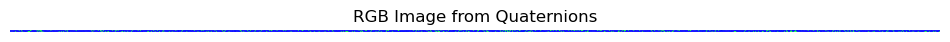

In [ ]:
# get clusters for clustered labels == 1
fz_data_labels_1 = sampled_fz_data[clustered_labels == 1]
print("Shape of fz data labels 1:", fz_data_labels_1.shape)  # Should be (N, 4) where N is the number of points in cluster 1

# now subsample fz_data_labels_1 for visualization, every 100th.
subsampled_fz_data_labels_1 = fz_data_labels_1[::100, :]  # Subsample every 100th quaternion for visualization
print("Shape of subsampled fz data labels 1:", subsampled_fz_data_labels_1.shape)  # Should be (N/100, 4) where N is the number of points in cluster 1

#Example with three orientations
Qs = subsampled_fz_data_labels_1  # Convert numpy array to list
# bring last quaternion dimension to the front (Scalar first)
# reshape Qs to (-1, 4) if needed
q = np.asarray(Qs).reshape(-1, 4)  # Flatten if necessary

# roll the last axis to the front (scalar first)
q = np.roll(q, shift=1, axis=-1)

print(q)  # prints quaternions in [s, x, y, z] order
rgbs = quaternion_to_ipf(q, axis="Z")  # ready for scatter
print(rgbs)  # prints RGB values in 0–1 range

print("Shape of rgbs:", rgbs.shape)  # Check the shape of the RGB array

#reshape rgbs to match the original data shape
rgbs_reshaped = rgbs.reshape(1, subsampled_fz_data_labels_1.shape[0], 3)
print("Shape of reshaped rgbs:", rgbs_reshaped.shape)  # Should match (1, -1, 3)

# Try to reshape to the closest possible square for visualization
n = subsampled_fz_data_labels_1.shape[0]
best_rows, best_cols = n, 1
min_diff = n  # initialize with max possible difference
for rows in range(1, n + 1):
    if n % rows == 0:
        cols = n // rows
        diff = abs(rows - cols)
        if diff < min_diff:
            min_diff = diff
            best_rows, best_cols = rows, cols
rows, cols = best_rows, best_cols

rgbs_reshaped_img = rgbs.reshape(rows, cols, 3)
print("Shape of reshaped rgbs for image:", rgbs_reshaped_img.shape)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.imshow(rgbs_reshaped_img)
plt.axis('off')
plt.title('RGB Image from Quaternions')
plt.show()